# RECIPE BOOK WITH ALLERGENS
## Alessandra D'Apolito, Cristina Papi, Marco Rosato

This project is focused on integrating two different datasets: [TheMealDB](https://www.themealdb.com/), a collection of recipe data obtained via **API**, and "[Food: Allergens and Allergies](https://www.kaggle.com/datasets/boltcutters/food-allergens-and-allergies)", a dataset downloaded from **Kaggle**. The goal of this work is to support individuals with food allergies by enriching recipe data with allergen information, enabling more informed and safer dietary choices.

To achieve this, two types of mapping strategies were employed:

*   A **lexical join**, based on direct string matching, to associate ingredients with known allergens.


*   A **semantic join**, leveraging word embeddings to identify allergens linked to ingredients even when exact lexical matches are absent.

This approach aims to capture both explicit and implicit allergen mentions, improving the coverage and reliability of allergen detection in recipe datasets.

Additionally, a preprocessing step was carried out to convert and standardize certain units of measurement in the recipe dataset, improving the consistency and reliability.







# LIBRARIES

In [ ]:
# --- Package Installation

!pip install pymongo
!pip install mlcroissant
!pip install pandas sentence-transformers torch numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 22.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 21.5 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=0fc7be362ed325edb9acba6e147af4ed9beb5ce8424d440a751e1baec0438334
  Stored in directory: /root/.cache/pip/wheels/53/cf/51/a4ea10224b7fdb523e18e2033cadf2a8657517d1f95f3f5413
Successfully built jsonpath-rw
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
# --- Library Imports

import time
import requests
import string
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi
import pandas as pd
from io import StringIO
import time
import zipfile
import os
import re
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np
import pandas as pd
import re
from fractions import Fraction
import matplotlib.pyplot as plt
import seaborn as sns


# DATA ACQUISITION

Two distinct methods of data acquisition were employed:

*   API Data Collection: a dataset was collected from TheMealDB API, an open-source database that provides information on a wide variety of meals and recipes.
*   Kaggle Dataset Download: a structured dataset was downloaded from Kaggle related to food and ingredient allergies


In [ ]:
# --- Download the recipes for each letter of the English alphabet

# Dataset meals:
alphabet = string.ascii_lowercase
all_recipes = []

start_time = time.time()
for letter in alphabet:
    response = requests.get(f'https://www.themealdb.com/api/json/v1/1/search.php?f={letter}')
    if response.status_code == 200:
        data = response.json()
        if 'meals' in data and data['meals']:

            print(f"Recipes starting with '{letter}': {len(data['meals'])}")

            for recipe in data["meals"]:
                recipe["starts_with"] = letter
                #collection.insert_one(recipe)
                all_recipes.append(recipe)

        else:
            print(f"No recipes found starting with '{letter}'")
    else:
        print(f"Failed to fetch data for letter '{letter}'")

    end_time = time.time()
    elapsed = end_time - start_time
    print(f"⏱️ Insert Time: {elapsed:.2f} seconds")

Recipes starting with 'a': 4
⏱️ Insert Time: 0.31 seconds
Recipes starting with 'b': 40
⏱️ Insert Time: 0.77 seconds
Recipes starting with 'c': 49
⏱️ Insert Time: 1.31 seconds
Recipes starting with 'd': 3
⏱️ Insert Time: 1.57 seconds
Recipes starting with 'e': 7
⏱️ Insert Time: 1.91 seconds
Recipes starting with 'f': 17
⏱️ Insert Time: 2.26 seconds
Recipes starting with 'g': 7
⏱️ Insert Time: 2.61 seconds
Recipes starting with 'h': 7
⏱️ Insert Time: 2.95 seconds
Recipes starting with 'i': 1
⏱️ Insert Time: 3.12 seconds
Recipes starting with 'j': 5
⏱️ Insert Time: 3.48 seconds
Recipes starting with 'k': 13
⏱️ Insert Time: 3.82 seconds
Recipes starting with 'l': 13
⏱️ Insert Time: 4.17 seconds
Recipes starting with 'm': 18
⏱️ Insert Time: 4.60 seconds
Recipes starting with 'n': 4
⏱️ Insert Time: 4.90 seconds
Recipes starting with 'o': 2
⏱️ Insert Time: 5.06 seconds
Recipes starting with 'p': 26
⏱️ Insert Time: 5.32 seconds
No recipes found starting with 'q'
⏱️ Insert Time: 5.59 seconds
R

In [ ]:
# --- Download and load the Allergies dataset from Kaggle

url = "https://www.kaggle.com/datasets/boltcutters/food-allergens-and-allergies"
print(f"Go manually to: {url}")
print("Download the FoodData.csv file and upload it using the button below:")

# Upload file manually
from google.colab import files
uploaded = files.upload()

# Read the uploaded file
for filename in uploaded.keys():
    if filename.endswith('.csv'):
        allergies_df = pd.read_csv(filename)
        print(f"File {filename} uploaded successfully!")
        print(f"Dimensions: {allergies_df.shape}")
        print("\nFirst rows:")
        print(allergies_df.head())
        break

    elif filename.endswith('.zip'):
        import zipfile
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')
        # Find the extracted CSV file
        import os
        csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
        if csv_files:
            allergies_df = pd.read_csv(csv_files[0])
            print(f"CSV file extracted and uploaded: {csv_files[0]}")
            print(f"Dimensions: {allergies_df.shape}")
            print(allergies_df.head())

Go manually to: https://www.kaggle.com/datasets/boltcutters/food-allergens-and-allergies
Download the FoodData.csv file and upload it using the button below:


Saving archive.zip to archive.zip
CSV file extracted and uploaded: FoodData.csv
Dimensions: (184, 5)
          Class          Type                 Group       Food  \
0  Plant origin  Nut and seed              Oil seed     Almond   
1  Plant origin         Fruit            Pome fruit      Apple   
2  Plant origin         Fruit           Stone fruit    Apricot   
3  Plant origin     Vegetable   Composite vegetable  Artichoke   
4  Plant origin     Vegetable  Liliaceous vegetable  Asparagus   

                 Allergy  
0            Nut Allergy  
1  Oral Allergy Syndrome  
2    Stone Fruit Allergy  
3        Insulin Allergy  
4         Allium Allergy  


#DATA PREPARATION

After we collect our data from API and Kaggle, we clean our data to analyze them. For both the dataset, we counted the missing values and we normalized the ingredient, measurement and food string values by removing leading and trailing whitespace and converting all text to lowercase, in order to make them easier to compare and analyze. For the first one we also converted most of the measurements into grams and milliliters to ensure a more consistent and understandable dataset (since many of the original units were uncommon in Italy)

## **Recipes dataset**

In [ ]:
# --- Print of the dataset

df1 = pd.DataFrame(all_recipes)
df1

,idMeal,strMeal,strMealAlternate,strCategory,strArea,strInstructions,strMealThumb,strTags,strYoutube,strIngredient1,...,strMeasure16,strMeasure17,strMeasure18,strMeasure19,strMeasure20,strSource,strImageSource,strCreativeCommonsConfirmed,dateModified,starts_with
0,52768,Apple Frangipan Tart,None,Dessert,British,Preheat the oven to 200C/180C Fan/Gas 6.\r\nPu...,https://www.themealdb.com/images/media/meals/w...,"Tart,Baking,Fruity",https://www.youtube.com/watch?v=rp8Slv4INLk,digestive biscuits,...,None,None,None,None,None,None,None,None,None,a
1,52893,Apple & Blackberry Crumble,None,Dessert,British,Heat oven to 190C/170C fan/gas 5. Tip the flou...,https://www.themealdb.com/images/media/meals/x...,Pudding,https://www.youtube.com/watch?v=4vhcOwVBDO4,Plain Flour,...,,,,,,https://www.bbcgoodfood.com/recipes/778642/app...,None,None,None,a
2,53049,Apam balik,None,Dessert,Malaysian,"Mix milk, oil and egg together. Sift flour, ba...",https://www.themealdb.com/images/media/meals/a...,None,https://www.youtube.com/watch?v=6R8ffRRJcrg,Milk,...,,,,,,https://www.nyonyacooking.com/recipes/apam-bal...,None,None,None,a
3,53050,Ayam Percik,None,Chicken,Malaysian,"In a blender, add the ingredients for the spic...",https://www.themealdb.com/images/media/meals/0...,None,https://www.youtube.com/watch?v=9ytR28QK6I8,Chicken Thighs,...,,,,,,http://www.curiousnut.com/roasted-spiced-chick...,None,None,None,a
4,52767,Bakewell tart,None,Dessert,British,"To make the pastry, measure the flour into a b...",https://www.themealdb.com/images/media/meals/w...,"Tart,Baking,Alcoholic",https://www.youtube.com/watch?v=1ahpSTf_Pvk,plain flour,...,None,None,None,None,None,None,None,None,None,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,53000,Vegetable Shepherds Pie,None,Beef,Irish,Add Ingredients:\r\n\r\n12 cups chopped mixed ...,https://www.themealdb.com/images/media/meals/w...,Baking,,Potatoes,...,2 sprigs,,,,,,None,None,None,v
298,52917,White chocolate creme brulee,None,Dessert,French,"Heat the cream, chocolate and vanilla pod in a...",https://www.themealdb.com/images/media/meals/u...,"Desert,DinnerParty,Pudding",https://www.youtube.com/watch?v=LmJ0lsPLHDc,Double Cream,...,,,,,,https://www.bbcgoodfood.com/recipes/2540/white...,None,None,None,w
299,52948,Wontons,None,Pork,Chinese,"Combine pork, garlic, ginger, soy sauce, sesam...",https://www.themealdb.com/images/media/meals/1...,MainMeal,https://www.youtube.com/watch?v=9h9No18ZyCI,Pork,...,,,,,,http://www.geniuskitchen.com/recipe/chinese-wo...,None,None,None,w
300,53062,Walnut Roll Gužvara,None,Dessert,Croatian,Mix all the ingredients for the dough together...,https://www.themealdb.com/images/media/meals/u...,Nutty,https://www.youtube.com/watch?v=Q_akngSJVrQ,Flour,...,,,,,,https://www.visit-croatia.co.uk/croatian-cuisi...,None,None,None,w


In [ ]:
# --- Number of missing values

missing_custom = df1.applymap(lambda x: pd.isna(x) or str(x).strip() == "").sum()
print("Missing Values Summary:\n", missing_custom)

Missing Values Summary:
 idMeal                           0
strMeal                          0
strMealAlternate               302
strCategory                      0
strArea                          0
strInstructions                  0
strMealThumb                     0
strTags                        120
strYoutube                      16
strIngredient1                   0
strIngredient2                   0
strIngredient3                   0
strIngredient4                   2
strIngredient5                  12
strIngredient6                  20
strIngredient7                  39
strIngredient8                  64
strIngredient9                  89
strIngredient10                121
strIngredient11                152
strIngredient12                178
strIngredient13                208
strIngredient14                231
strIngredient15                246
strIngredient16                264
strIngredient17                274
strIngredient18                285
strIngredient19               

/tmp/ipython-input-6-3452916977.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  missing_custom = df1.applymap(lambda x: pd.isna(x) or str(x).strip() == "").sum()


In [ ]:
# --- Delete variables that have 302 missing values (all the values)

df1.drop(['strMealAlternate', 'strImageSource', 'strCreativeCommonsConfirmed', 'dateModified', 'starts_with'], axis=1, inplace=True)

In [ ]:
df1

,idMeal,strMeal,strCategory,strArea,strInstructions,strMealThumb,strTags,strYoutube,strIngredient1,strIngredient2,...,strMeasure12,strMeasure13,strMeasure14,strMeasure15,strMeasure16,strMeasure17,strMeasure18,strMeasure19,strMeasure20,strSource
0,52768,Apple Frangipan Tart,Dessert,British,Preheat the oven to 200C/180C Fan/Gas 6.\r\nPu...,https://www.themealdb.com/images/media/meals/w...,"Tart,Baking,Fruity",https://www.youtube.com/watch?v=rp8Slv4INLk,digestive biscuits,butter,...,,,,,None,None,None,None,None,None
1,52893,Apple & Blackberry Crumble,Dessert,British,Heat oven to 190C/170C fan/gas 5. Tip the flou...,https://www.themealdb.com/images/media/meals/x...,Pudding,https://www.youtube.com/watch?v=4vhcOwVBDO4,Plain Flour,Caster Sugar,...,,,,,,,,,,https://www.bbcgoodfood.com/recipes/778642/app...
2,53049,Apam balik,Dessert,Malaysian,"Mix milk, oil and egg together. Sift flour, ba...",https://www.themealdb.com/images/media/meals/a...,None,https://www.youtube.com/watch?v=6R8ffRRJcrg,Milk,Oil,...,,,,,,,,,,https://www.nyonyacooking.com/recipes/apam-bal...
3,53050,Ayam Percik,Chicken,Malaysian,"In a blender, add the ingredients for the spic...",https://www.themealdb.com/images/media/meals/0...,None,https://www.youtube.com/watch?v=9ytR28QK6I8,Chicken Thighs,Challots,...,1 tsp,1 cup,,,,,,,,http://www.curiousnut.com/roasted-spiced-chick...
4,52767,Bakewell tart,Dessert,British,"To make the pastry, measure the flour into a b...",https://www.themealdb.com/images/media/meals/w...,"Tart,Baking,Alcoholic",https://www.youtube.com/watch?v=1ahpSTf_Pvk,plain flour,chilled butter,...,,,,,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,53000,Vegetable Shepherds Pie,Beef,Irish,Add Ingredients:\r\n\r\n12 cups chopped mixed ...,https://www.themealdb.com/images/media/meals/w...,Baking,,Potatoes,Small Potatoes,...,2 cups,8 cups,2 tbsp,2 tsp,2 sprigs,,,,,
298,52917,White chocolate creme brulee,Dessert,French,"Heat the cream, chocolate and vanilla pod in a...",https://www.themealdb.com/images/media/meals/u...,"Desert,DinnerParty,Pudding",https://www.youtube.com/watch?v=LmJ0lsPLHDc,Double Cream,White Chocolate Chips,...,,,,,,,,,,https://www.bbcgoodfood.com/recipes/2540/white...
299,52948,Wontons,Pork,Chinese,"Combine pork, garlic, ginger, soy sauce, sesam...",https://www.themealdb.com/images/media/meals/1...,MainMeal,https://www.youtube.com/watch?v=9h9No18ZyCI,Pork,Garlic Clove,...,,,,,,,,,,http://www.geniuskitchen.com/recipe/chinese-wo...
300,53062,Walnut Roll Gužvara,Dessert,Croatian,Mix all the ingredients for the dough together...,https://www.themealdb.com/images/media/meals/u...,Nutty,https://www.youtube.com/watch?v=Q_akngSJVrQ,Flour,Caster Sugar,...,To Glaze,To Glaze,,,,,,,,https://www.visit-croatia.co.uk/croatian-cuisi...


In [ ]:
# --- Convertion to lowercase of the meal string values

df1['strMeal'] = df1['strMeal'].str.lower()

In [ ]:
# --- Normalization of the ingredients string values and convertion to lowercase

ingredient_cols = [f'strIngredient{i}' for i in range(1, 21)]
df1[ingredient_cols] = df1[ingredient_cols].apply(lambda x: x.str.strip().str.lower())

In [ ]:
# --- Normalization of the measures string values and convertion to lowercase

measure_cols = [f'strMeasure{i}' for i in range(1, 21)]
df1[measure_cols] = df1[measure_cols].apply(lambda x: x.str.strip().str.lower())

Convertion of most of the measurements into grams and milliliters

In [ ]:
# --- Conversion tables
unit_to_grams = {
    'g': 1, 'kg': 1000, 'mg': 0.001,
    'lb': 453.592, 'pound': 453.592,
    'oz': 28.3495, 'ounces': 28.3495
}

unit_to_ml = {
    'ml': 1, 'l': 1000, 'pint': 473,
    'quart': 946, 'gallon': 3785,
    'cup': 240, 'cups': 240,
    'tablespoon': 15, 'tbsp': 15,
    'tbs': 15, 'tbsb': 15,
    'teaspoon': 5, 'tsp': 5
}

unit_aliases = {
    'tbsb': 'tbsp', 'tbs': 'tbsp',
    'tablespoon': 'tbsp', 'tablespoons': 'tbsp',
    'teaspoon': 'tsp', 'teaspoons': 'tsp',
    'cups': 'cup', 'ounces': 'oz',
    'pounds': 'lb'
}

not_convertible = [
    "egg", "eggs", "packet", "pack", "slice", "slices",
    "clove", "cloves", "bustina", "bustine", "pezzo", "pezzi"
]

In [ ]:
# --- Function to parse measurement units
def parse_quantity(amount_str):
    amount_str = amount_str.strip()
    try:
        if '-' in amount_str:
            a, b = amount_str.split('-')
            return (float(a) + float(b)) / 2
        return float(Fraction(amount_str))
    except:
        return None

In [ ]:
# --- Measurement conversion function
def convert_line(measure, ingredient):
    if pd.isna(ingredient) or str(ingredient).strip() == '':
        return None
    ingredient = str(ingredient).strip().lower()
    measure = str(measure).strip().lower() if pd.notna(measure) else ""


    if any(word in ingredient for word in not_convertible):
        return f"{measure}".strip()
    # Split quantity and unit
    match = re.match(r"([\d\s\/\.,\-]+)?\s*([a-zA-Z]+)?", measure)
    if not match:
        return f"{measure}".strip()

    qty_str, unit_raw = match.groups()
    qty = parse_quantity(qty_str) if qty_str else 1
    if qty is None:
        return f"{measure}".strip()

    unit = unit_raw.lower() if unit_raw else ''
    unit = unit_aliases.get(unit, unit)

    if unit in unit_to_grams:
        value = qty * unit_to_grams[unit]
        return f"{value:.1f} g"
    elif unit in unit_to_ml:
        value = qty * unit_to_ml[unit]
        return f"{value:.1f} ml"
    else:
    # If unit is unknown, keep the original text
        return measure.strip()

In [ ]:
# --- Application

results = []

for i in range(1, 21):
    measure_col = f"strMeasure{i}"
    ingredient_col = f"strIngredient{i}"
    output_col = f"Measure{i}_converted"

    df1[output_col] = df1.apply(
        lambda row: convert_line(row.get(measure_col), row.get(ingredient_col)),
        axis=1
    )

    results.append(output_col)

In [ ]:
# --- Results
columns_to_show = ['idMeal', 'strMeal'] + results
print(df1[columns_to_show].head())

# --- CSV
df1.to_csv("ricette_convertite_comp.csv", index=False)

  idMeal                     strMeal Measure1_converted Measure2_converted  \
0  52768        apple frangipan tart            175.0 g             75.0 g   
1  52893  apple & blackberry crumble            120.0 g             60.0 g   
2  53049                  apam balik           200.0 ml            60.0 ml   
3  53050                 ayam percik                  6                 16   
4  52767               bakewell tart            175.0 g             75.0 g   

  Measure3_converted Measure4_converted Measure5_converted Measure6_converted  \
0            200.0 g             75.0 g             75.0 g                  2   
1             60.0 g            300.0 g             30.0 g             30.0 g   
2                  2           1600.0 g            15.0 ml             2.5 ml   
3              1 1/2                  6                  8            30.0 ml   
4            37.5 ml            15.0 ml            125.0 g            125.0 g   

  Measure7_converted Measure8_converted  ...

In [ ]:
# --- Open the new file that was just created

df_comp=pd.read_csv("ricette_convertite_comp.csv", delimiter=",")

In [ ]:
# --- Delete 20 columns strMeasure not converted

df_comp.drop(measure_cols, axis=1, inplace=True)

In [ ]:
# --- Save our final dataset in a CSV file

df_comp.to_csv("ricette_convertite_final.csv", index=False)

### Recipes dataset graphs

/tmp/ipython-input-20-700732423.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


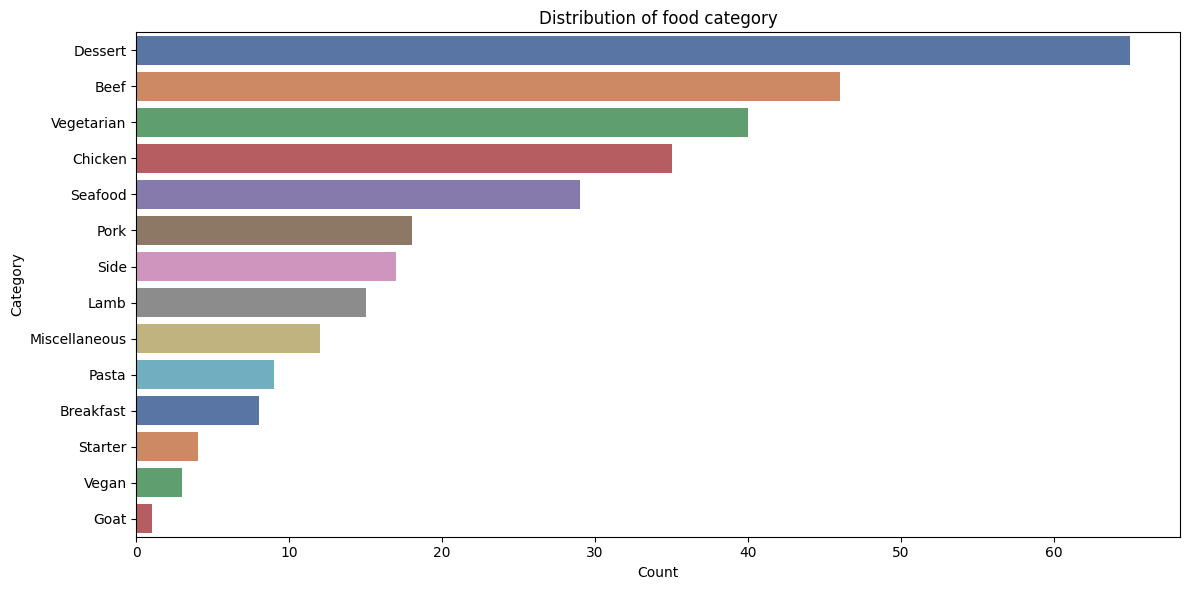

In [ ]:
# --- Distribution of food category

palette = sns.color_palette("deep", n_colors=df_comp['strCategory'].nunique())

plt.figure(figsize=(12, 6))
sns.countplot(
    y='strCategory',
    data=df_comp,
    order=df_comp['strCategory'].value_counts().index,
    palette=palette
)
plt.title('Distribution of food category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipython-input-21-423933374.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


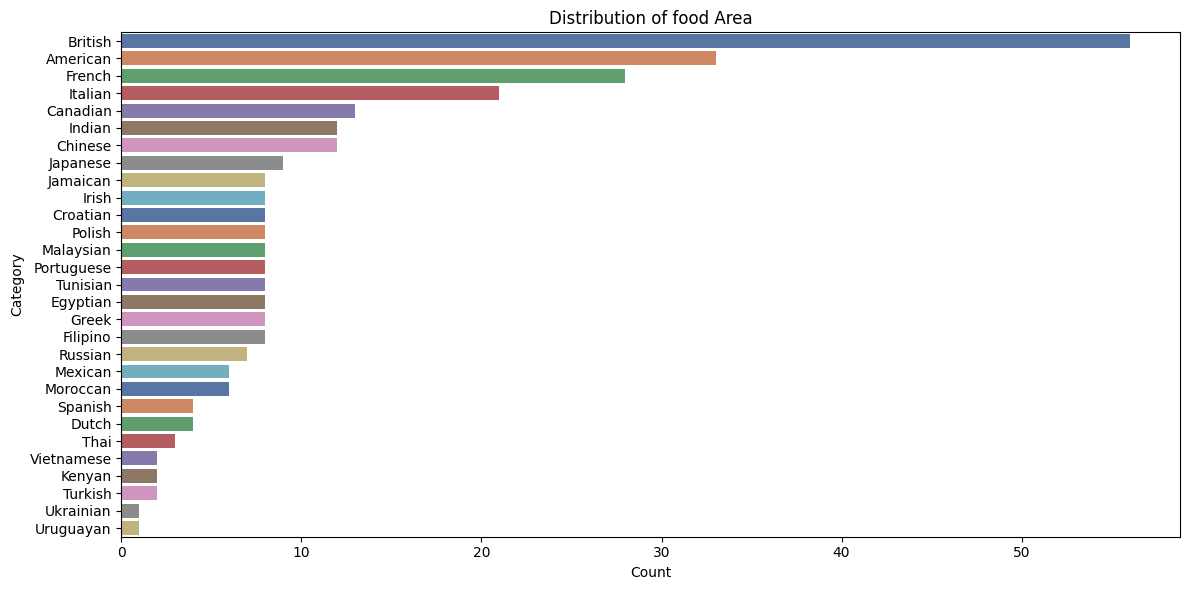

In [ ]:
# --- Distribution of food origin

palette = sns.color_palette("deep", n_colors=df_comp['strArea'].nunique())

plt.figure(figsize=(12, 6))
sns.countplot(
    y='strArea',
    data=df_comp,
    order=df_comp['strArea'].value_counts().index,
    palette=palette
)
plt.title('Distribution of food Area')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## **Allergies Dataset**

In [ ]:
# --- Print of the dataset

allergies_df

,Class,Type,Group,Food,Allergy
0,Plant origin,Nut and seed,Oil seed,Almond,Nut Allergy
1,Plant origin,Fruit,Pome fruit,Apple,Oral Allergy Syndrome
2,Plant origin,Fruit,Stone fruit,Apricot,Stone Fruit Allergy
3,Plant origin,Vegetable,Composite vegetable,Artichoke,Insulin Allergy
4,Plant origin,Vegetable,Liliaceous vegetable,Asparagus,Allium Allergy
...,...,...,...,...,...
179,Plant origin,Cereal grain and pulse,Cereal grain,Wheat,Gluten Allergy
180,Animal origin,Dairy,Dairy,Whey,Milk allergy / Lactose intolerance
181,Plant origin,Cereal grain and pulse,Pulse,White bean,Legume Allergy
182,Plant origin,Vegetable,Potato,Yam,Potato Allergy


In [ ]:
# --- Number of missing values

missing_custom2 = allergies_df.applymap(lambda x: pd.isna(x) or str(x).strip() == "").sum()
print("Missing Values Summary:\n", missing_custom2)

Missing Values Summary:
 Class       0
Type        0
Group       0
Food        0
Allergy    22
dtype: int64


/tmp/ipython-input-23-553970615.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  missing_custom2 = allergies_df.applymap(lambda x: pd.isna(x) or str(x).strip() == "").sum()


In [ ]:
# --- Normalization of the Food string values and convertion to lowercase

allergies_df['Food'] = allergies_df['Food'].str.strip().str.lower()

In [ ]:
# --- Replacement of missing values with "Unknown" string

allergies_df['Allergy'] = allergies_df['Allergy'].fillna('Unknown')

### Allergies dataset graphs

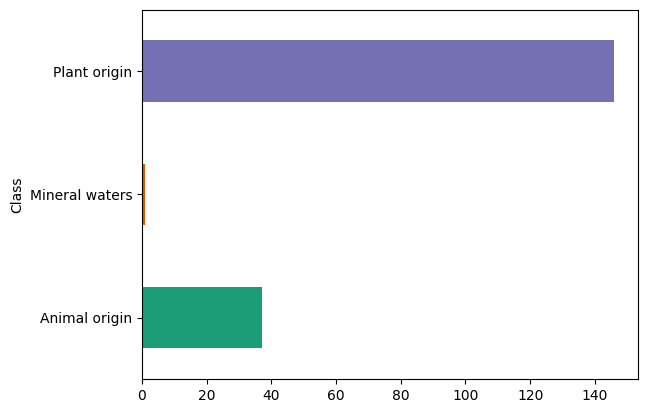

In [ ]:
# --- Origins of allergens

ax = allergies_df.groupby('Class').size().plot(kind='barh', color=sns.color_palette('Dark2'))

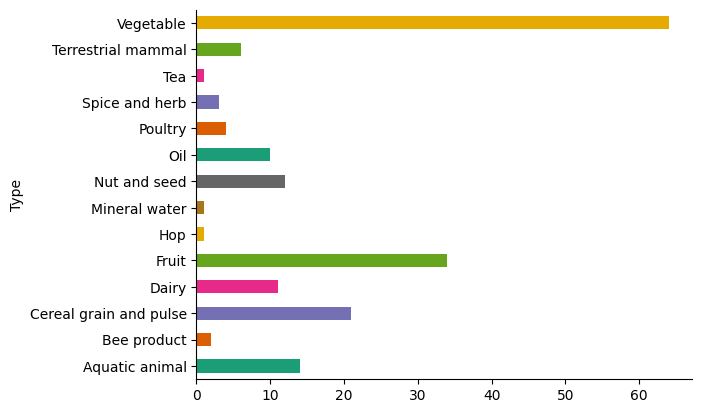

In [ ]:
# --- Type of allergens

ax = allergies_df.groupby('Type').size().plot(kind='barh', color=sns.color_palette('Dark2'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

**Normalization Process**

The original wide-format recipe dataset, containing up to 20 ingredient columns (strIngredient1-20) and corresponding measure columns (Measure1-20), undergoes a transformation process:

Unpivoting: Ingredient and measure columns are melted into long format
Position Tracking: Each ingredient retains its original position within the recipe
Data Cleaning: Empty ingredients and measures are filtered out
Deduplication: Duplicate allergy records are removed, keeping the most recent entries

In [ ]:
# Splitting the table Recipes

all_recipes_df = df_comp

# list of columns
ingredient_cols = [f'strIngredient{i}' for i in range(1, 21)]
measure_cols = [f'Measure{i}_converted' for i in range(1, 21)]

# filter of the columns
ingredient_cols = [col for col in ingredient_cols if col in all_recipes_df.columns]
measure_cols = [col for col in measure_cols if col in all_recipes_df.columns]

# Reduce df
all_columns = ['idMeal'] + ingredient_cols + measure_cols
all_Ingredients_df = all_recipes_df[all_columns]

# Unpivot ingredients
ingredients_long = all_Ingredients_df.melt(
    id_vars=['idMeal'],
    value_vars=ingredient_cols,
    var_name='ingredient_position',
    value_name='Ingredient'
)

# Unpivot measures
measures_long = all_Ingredients_df.melt(
    id_vars=['idMeal'],
    value_vars=measure_cols,
    var_name='measure_position',
    value_name='Measure'
)

# extracting the number of the position
ingredients_long['Position'] = ingredients_long['ingredient_position'].str.extract(r'(\d+)').astype(int)
measures_long['Position'] = measures_long['measure_position'].str.extract(r'(\d+)').astype(int)

# Unify the two dfs
final_ingredients_df = pd.merge(
    ingredients_long[['idMeal' , 'Position', 'Ingredient']],
    measures_long[['idMeal', 'Position', 'Measure']],
    on=['idMeal','Position']
)

# removing empty cells
final_ingredients_df = final_ingredients_df.dropna(subset=['Ingredient', 'Measure'])
final_ingredients_df = final_ingredients_df[
    (final_ingredients_df['Ingredient'].astype(str).str.strip() != '') &
    (final_ingredients_df['Measure'].astype(str).str.strip() != '')
]

final_ingredients_df

,idMeal,Position,Ingredient,Measure
0,52768,1,digestive biscuits,175.0 g
1,52893,1,plain flour,120.0 g
2,53049,1,milk,200.0 ml
3,53050,1,chicken thighs,6
4,52767,1,plain flour,175.0 g
...,...,...,...,...
5860,52951,20,ginger,5.0 ml
5874,52937,20,kidney beans,800.0 g
5875,52938,20,water,60.0 ml
5892,52805,20,biryani masala,15.0 ml


In [ ]:
print(final_ingredients_df[final_ingredients_df['idMeal']==53049])

      idMeal  Position       Ingredient   Measure
2      53049         1             milk  200.0 ml
304    53049         2              oil   60.0 ml
606    53049         3             eggs         2
908    53049         4            flour  1600.0 g
1210   53049         5    baking powder   15.0 ml
1512   53049         6             salt    2.5 ml
1814   53049         7  unsalted butter    25.0 g
2116   53049         8            sugar    45.0 g
2418   53049         9    peanut butter   45.0 ml


Checking for duplicates in the dataframes

In [ ]:
print('Check if there are any duplicates in allergies_df')

duplicates = allergies_df[allergies_df['Food'].duplicated(keep=False)]
print(f"Numbers of duplicate rows: {len(duplicates)}")

if len(duplicates) > 0:
    print("\nDuplicated values:")
    print(duplicates.sort_values('Food'))

    print("\nCount for each duplicated value:")
    duplicate_counts = allergies_df['Food'].value_counts()
    duplicate_foods = duplicate_counts[duplicate_counts > 1]
    print(duplicate_foods)

Check if there are any duplicates in allergies_df
Numbers of duplicate rows: 2

Duplicated values:
            Class                    Type              Group  Food  \
115  Plant origin               Vegetable  Legumes vegetable  peas   
116  Plant origin  Cereal grain and pulse              Pulse  peas   

            Allergy  
115  Legume Allergy  
116  Legume Allergy  

Count for each duplicated value:
Food
peas    2
Name: count, dtype: int64


In [ ]:
# Deleting duplicates in allergies_df

print("Removing Duplicates")
allergies_df_clean = allergies_df.drop_duplicates(subset=['Food'], keep='last')
print(f"Before: {len(allergies_df)} rows → After: {len(allergies_df_clean)} rows")

Removing Duplicates
Before: 184 rows → After: 183 rows


In [ ]:
#Verify whether the duplicate values have been successfully removed
print(allergies_df_clean[allergies_df_clean['Food']=='peas'])

            Class                    Type  Group  Food         Allergy
116  Plant origin  Cereal grain and pulse  Pulse  peas  Legume Allergy


In [ ]:
print('Check if there are any duplicates in recipes_df')

duplicates = all_recipes_df[all_recipes_df['idMeal'].duplicated(keep=False)]
print(f"Numbers of duplicate rows: {len(duplicates)}")

if len(duplicates) > 0:
    print("\nDuplicated values:")
    print(duplicates.sort_values('idMeal'))

    print("\nCount for each duplicated value:")
    duplicate_counts = all_recipes_df['idMeal'].value_counts()
    duplicate_foods = duplicate_counts[duplicate_counts > 1]
    print(duplicate_foods)

Check if there are any duplicates in recipes_df
Numbers of duplicate rows: 0


In [ ]:
allergies_df_clean

,Class,Type,Group,Food,Allergy
0,Plant origin,Nut and seed,Oil seed,almond,Nut Allergy
1,Plant origin,Fruit,Pome fruit,apple,Oral Allergy Syndrome
2,Plant origin,Fruit,Stone fruit,apricot,Stone Fruit Allergy
3,Plant origin,Vegetable,Composite vegetable,artichoke,Insulin Allergy
4,Plant origin,Vegetable,Liliaceous vegetable,asparagus,Allium Allergy
...,...,...,...,...,...
179,Plant origin,Cereal grain and pulse,Cereal grain,wheat,Gluten Allergy
180,Animal origin,Dairy,Dairy,whey,Milk allergy / Lactose intolerance
181,Plant origin,Cereal grain and pulse,Pulse,white bean,Legume Allergy
182,Plant origin,Vegetable,Potato,yam,Potato Allergy


# DATA STORAGE

This part of the project implements a MongoDB-based data storage solution for a recipe management system that processes two primary datasets: recipes and food allergies.
The system transforms flat, denormalized recipe data into a normalized star schema structure optimized for efficient querying and analysis.

**Database Connection**

The system connects to MongoDB Atlas using a cloud-hosted cluster (ClusterRecipes) with proper authentication and connection pooling.
The database DataManagementProject serves as the main container for all collections.

**Collections Structure**

The data model implements a star schema with the following collections:

Recipes (Fact Table): Core recipe information including ID, name, category, cuisine area, instructions, and media links

Ingredients (Dimension Table): Normalized ingredient data with recipe associations, ingredient names, and measurements

Allergies (Dimension Table): Food allergy information mapping ingredients to their allergenic properties

recipes_to_ingredients (Joined Collection): Aggregated view for complex queries involving recipe-ingredients relationships

ingredients_with_Allergies (Joined Collection):  Aggregated view for complex queries involving ingredients -allergy relationships

recipes_with_allergies (Joined Collection):  Aggregated view for complex queries involving recipe-allergy relationships

In [ ]:
# Connecting to MongoDB
uri = "mongodb+srv://DATA_MANAGEMENT_MONGODB_LINK"

# Create a new client and connect to the server
client = MongoClient(uri, server_api=ServerApi('1'))

# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)


# Connecting to the DB
db = client["DataManagementProject"]

# Collections setup
recipes_coll = db["Recipes"]
ingredients_coll = db["Ingredients"]
allergies_coll = db["Allergies"]
ingredients_with_Allergies_coll = db["ingredients_with_Allergies"]
recipes_to_ingredients_coll = db["recipes_to_ingredients"]
recipes_with_allergies_coll = db["recipes_with_allergies"]

Pinged your deployment. You successfully connected to MongoDB!


In [ ]:
# Clean existing collections
recipes_coll.drop()
ingredients_coll.drop()
allergies_coll.drop()

# Inserting values in no joined collection
ingredients_df = final_ingredients_df[['idMeal', 'Ingredient', 'Measure']].reset_index(drop=True)

print("Inserting allergies data...")
ingredients_coll.insert_many(final_ingredients_df.to_dict('records'))
print(f"Inserted {len(final_ingredients_df)} ingredients")

recipes_df = all_recipes_df[['idMeal', 'strMeal', 'strCategory', 'strArea', 'strInstructions', 'strMealThumb', 'strTags', 'strYoutube']]

print("Inserting recipes data...")
recipes_coll.insert_many(recipes_df.to_dict('records'))
print(f"Inserted {len(recipes_df)} recipes")

print("Inserting allergies data...")
allergies_coll.insert_many(allergies_df_clean.to_dict('records'))
print(f"Inserted {len(allergies_df_clean)} allergies")


Inserting allergies data...
Inserted 3243 ingredients
Inserting recipes data...
Inserted 302 recipes
Inserting allergies data...
Inserted 183 allergies


## Data Model

**Indexing Strategy**
Performance optimization is achieved through strategic indexing:

Primary Keys: Unique indexes on idMeal (recipes) and Food (allergies)
Query Optimization: Compound indexes on frequently queried fields like recipe categories, cuisine areas, and ingredient names
Join Optimization: Multi-field indexes supporting ingredient-recipe-measure relationships

This normalized structure enables efficient ingredient-based searches, allergy cross-referencing, and complex recipe analytics while maintaining data integrity and query performance.

In [ ]:
#Indexes

recipes_coll.create_index("idMeal", unique=True)
recipes_coll.create_index("strCategory")
recipes_coll.create_index("strArea")

ingredients_coll.create_index("idMeal")
ingredients_coll.create_index("Ingredient")
ingredients_coll.create_index([("idMeal", 1), ("Ingredient", 1),("Measure", 1)])

allergies_coll.create_index("Food", unique=True)

print("Indexes created successfully!")

Indexes created successfully!


## Analysis with querying

This query below is intended to see if all the records has been loaded in MongoDB

In [ ]:
# Statistics of the model
total_recipes = recipes_coll.count_documents({})
total_ingredients = ingredients_coll.count_documents({})
total_allergies = allergies_coll.count_documents({})

print(f"Star Schema Statistics:")
print(f"Total Recipes (Fact table): {total_recipes}")
print(f"Total Ingredients (Dimension): {total_ingredients}")
print(f"Total Allergies (Dimension): {total_allergies}")

Star Schema Statistics:
Total Recipes (Fact table): 302
Total Ingredients (Dimension): 3243
Total Allergies (Dimension): 183


This query below is intended to see which allergens are the most commod.
The following result shows that the value 'Unknown' appears frequently. Therefore, the next aggregation pipelines will explicitly account for this case to ensure it is excluded from the output.

In [ ]:
# ALLERGEN DISTRIBUTION

print("\n=== ALLERGEN DISTRIBUTION ===")

# Count most common allergens
allergen_distribution = list(allergies_coll.aggregate([
    {"$group": {
        "_id": "$Allergy",
        "count": {"$sum": 1}
    }},
    {"$sort": {"count": -1}},
    {"$limit": 10}
]))

print("Top 10 allergens by frequency:")
for allergen in allergen_distribution:
    print(f"  -  {allergen['_id']}: {allergen['count']} foods")



=== ALLERGEN DISTRIBUTION ===
Top 10 allergens by frequency:
  -  Unknown: 22 foods
  -  Oral Allergy Syndrome: 13 foods
  -  Legume Allergy: 13 foods
  -  Fish Allergy: 12 foods
  -  Milk allergy / Lactose intolerance: 11 foods
  -  Cruciferous Allergy: 9 foods
  -  Allium Allergy: 7 foods
  -  Stone Fruit Allergy: 7 foods
  -  Hypersensitivity: 6 foods
  -  Salicylate Allergy: 6 foods


This query below is intended to identify any potential data quality issues. While the results include some unusual values, we chose not to modify them, as they are too general to be clearly defined or categorized.

In [ ]:
# SAMPLE PROBLEMATIC DATA

print("\n=== SAMPLE PROBLEMATIC DATA ===")

# Show recipes with very few ingredients (potential data quality issues)
recipes_few_ingredients = list(recipes_to_ingredients_coll.find({
    "$expr": {"$lt": [{"$size": "$ingredients"}, 3]}
}).limit(5))

print(f"Recipes with < 3 ingredients: {len(recipes_few_ingredients)}")
for recipe in recipes_few_ingredients:
    print(f"  - {recipe['strMeal']}: {len(recipe['ingredients'])} ingredients")

# Show ingredients with unusual measurements
unusual_measurements = list(ingredients_coll.find({
    "Measure": {"$regex": "^[a-zA-Z]+$"}  # Only letters, no numbers
}).limit(5))

print(f"\nIngredients with unusual measurements (sample):")
for ingredient in unusual_measurements:
    print(f"  - {ingredient['Ingredient']}: {ingredient['Measure']}")



=== SAMPLE PROBLEMATIC DATA ===
Recipes with < 3 ingredients: 0

Ingredients with unusual measurements (sample):
  - rice: white
  - butter: knob
  - sea salt: handful
  - vegetable oil: dash
  - salt: dash


#DATA INTEGRATION

This part of the project uses MongoDB to create a recipe recommendation system with allergy information. The chapter demonstrates practical database joining for food recommendations while highlighting the importance of consistent data naming across collections.

**Data Joining**

Uses MongoDB aggregation pipelines to join three collections - recipes, ingredients, and allergies - creating a comprehensive dataset that links recipes to their potential allergens.

**Interactive Recipe Search**
Implements a user workflow where people can input available ingredients to find matching recipes, view ingredient lists with measurements, access cooking instructions, and check for allergens.

**Data Quality Issues**

Identifies misalignment between ingredient names in different collections, causing incomplete allergy information and some allergens incorrectly labeled as "Unknown."

**Technical Approach**

Employs MongoDB operations like \$lookup, \$unwind, and \$group to process and join data, with filtering to remove null values and unknown allergens.

## Lexical join

In [ ]:
#Ingredient with allergies

ingredients_with_Allergies_coll.drop()

pipeline = [
    {"$lookup": {
        "from": "Allergies",
        "localField": "Ingredient",
        "foreignField": "Food",
        "as": "allergy_info"
    }},
    {"$project": {
        "_id": 0,
        "Ingredient": 1,
        "allergy": "$allergy_info.Allergy"
    }}
]

# Execute the join
joined_results = list(ingredients_coll.aggregate(pipeline))

#Removing _id from each document to avoid duplication error
for doc in joined_results:
    doc.pop("_id", None)

# Save to MongoDB
print("Saving joined data...")
ingredients_with_Allergies_coll.insert_many(joined_results)
print(f"Inserted {len(joined_results)} joined records")

Saving joined data...
Inserted 3243 joined records


In [ ]:
recipes_to_ingredients_coll.drop()

pipeline = [
    {
        "$lookup": {
            "from": "Ingredients",
            "localField": "idMeal",
            "foreignField": "idMeal",
            "as": "ingredients"
        }
    },
    {
        "$project": {
            "_id": 0,
            "idMeal": 1,
            "strMeal": 1,
            "ingredients.Ingredient": 1,
            "ingredients.Measure": 1
        }
    }
]

# Execute the join
joined_results = list(recipes_coll.aggregate(pipeline))

#Removing _id from each document to avoid duplication error
for doc in joined_results:
    doc.pop("_id", None)

# Save to MongoDB
print("Saving joined data...")
recipes_to_ingredients_coll.insert_many(joined_results)
print(f"Inserted {len(joined_results)} joined records")

Saving joined data...
Inserted 302 joined records


In [ ]:
#recipes with the ingredients and the corresponding allergies

recipes_with_allergies_coll.drop()

pipeline = [
    # Unwind to flat the array of the ingredients
    {"$unwind": "$ingredients"},

    # Lookup for the collection ingredients_with_Allergies
    {
        "$lookup": {
            "from": "ingredients_with_Allergies",
            "localField": "ingredients.Ingredient",
            "foreignField": "Ingredient",
            "as": "allergy_info"
        }
    },

    # Unwind to keep the documents without allergens
    {"$unwind": {"path": "$allergy_info", "preserveNullAndEmptyArrays": True}},

    # Unwind for the allergens
    {"$unwind": {"path": "$allergy_info.allergy", "preserveNullAndEmptyArrays": True}},

    # group by recipe
    {
        "$group": {
            "_id": "$idMeal",
            "strMeal": {"$first": "$strMeal"},
            "ingredients": {
                "$addToSet": {
                    "Ingredient": "$ingredients.Ingredient",
                    "Measure": "$ingredients.Measure"
                }
            },
            "allergies": {"$addToSet": "$allergy_info.allergy"}
        }
    },

    # Remove null values and 'Unknown'
    {
        "$addFields": {
            "allergies": {
                "$filter": {
                    "input": "$allergies",
                    "cond": {"$ne": ["$$this", None]},
                    "cond": {"$ne": ["$$this", "Unknown"]}
                }
            }
        }
    },

    # Final view
    {
        "$project": {
            "_id": 0,
            "idMeal": "$_id",
            "strMeal": 1,
            "ingredients": 1,
            "allergies": 1
        }
    }
]

# Execute
joined_results = list(recipes_to_ingredients_coll.aggregate(pipeline))

# Save to MongoDB
print("Saving joined data...")
if joined_results:
    recipes_with_allergies_coll.insert_many(joined_results)
    print(f"Inserted {len(joined_results)} joined records with allergies")
else:
    print("No documents to insert.")

Saving joined data...
Inserted 302 joined records with allergies


From this result we can see that some allergens are not correct, due to the differences between the values Ingredients and Food in the two collections.

In [ ]:
print("\n--- Allergies found via Lexical Join")

query = {
    "$and": [
        { "allergy": { "$ne": [] } },
        { "allergy": { "$nin": ["Unknown"] } }
    ]
}

list_of_single_ingredients = ingredients_with_Allergies_coll.distinct("allergy", query)

if list_of_single_ingredients:
    print("\nThe following allergies were found with the Lexical Join:")
    for allergene in sorted(list_of_single_ingredients):
        print(f"- {allergene}")
else:
    print("No allergies were found using the lexical join.")



--- Allergies found via Lexical Join

The following allergies were found with the Lexical Join:
- Allium Allergy
- Banana Allergy
- Broccoli allergy
- Citrus Allergy
- Cruciferous Allergy
- Fish Allergy
- Gluten Allergy
- Histamine Allergy
- Honey Allergy
- Hypersensitivity
- LTP Allergy
- Legume Allergy
- Milk allergy / Lactose intolerance
- Nightshade Allergy
- Oral Allergy Syndrome
- Poultry Allergy
- Rice Allergy
- Seed Allergy
- Stone Fruit Allergy
- Sugar Allergy / Intolerance


In [ ]:
# --- Pizza print lexical join

recipe_name_to_find = "Pizza Express Margherita"

recipe_doc = recipes_with_allergies_coll.find_one({
    "strMeal": {"$regex": f"^{re.escape(recipe_name_to_find)}$", "$options": "i"}
})

print(f"--- Analysis for: {recipe_name_to_find}")

ingredients = recipe_doc.get('ingredients', [])
allergens   = recipe_doc.get('allergies', [])

print("\nIngredients:")
for ing in sorted(ingredients, key=lambda x: x.get('Ingredient', '')):
  print(f"- {ing.get('Ingredient')}")

print("\nAllergens:")
if allergens:
    for allergen in sorted(allergens):
        print(f"- {allergen}")
else:
    print("No known allergens found for this recipe.")

--- Analysis for: Pizza Express Margherita

Ingredients:
- basil
- black pepper
- mozzarella
- olive oil
- oregano
- passata
- plain flour
- salt
- sugar
- water
- yeast

Allergens:
- Sugar Allergy / Intolerance


### Comment of this result

As we can see, even though the allergy "Milk allergy / Lactose intolerance" was detected, it does not appear in the list of allergens for the recipe "Pizza Express Margherita", because the ingredient "mozzarella" was not included in the Allergies dataset. On the other hand, the ingredient "cream" was present in the Allergies dataset, and the lexical join correctly associated it with "Milk allergy / Lactose intolerance", which appears in the list of allergens for the recipe "Strawberries Romanoff"



In [ ]:
# --- Strawberries Romanoff print lexical join

recipe_name_to_find = "Strawberries Romanoff"

recipe_doc = recipes_with_allergies_coll.find_one({
    "strMeal": {"$regex": f"^{re.escape(recipe_name_to_find)}$", "$options": "i"}
})

print(f"--- Analysis for: {recipe_name_to_find}")

ingredients = recipe_doc.get('ingredients', [])
allergens   = recipe_doc.get('allergies', [])

print("\nIngredients:")
for ing in sorted(ingredients, key=lambda x: x.get('Ingredient', '')):
  print(f"- {ing.get('Ingredient')}")

print("\nAllergens:")
if allergens:
    for allergen in sorted(allergens):
        print(f"- {allergen}")
else:
    print("No known allergens found for this recipe.")

--- Analysis for: Strawberries Romanoff

Ingredients:
- cream
- grand marnier
- sour cream
- strawberries
- sugar

Allergens:
- Milk allergy / Lactose intolerance
- Sugar Allergy / Intolerance


## Analysis with querying

In [ ]:
# DATA CONSISTENCY CHECKS


print("\n=== DATA CONSISTENCY CHECKS ===")

# Check for recipes without ingredients
recipes_without_ingredients = recipes_to_ingredients_coll.count_documents({
    "$or": [
        {"ingredients": {"$exists": False}},
        {"ingredients": {"$size": 0}}
    ]
})
print(f"Recipes without ingredients: {recipes_without_ingredients}")

# Check for orphaned ingredients (ingredients without corresponding recipes)
orphaned_ingredients = list(ingredients_coll.aggregate([
    {"$lookup": {
        "from": "Recipes",
        "localField": "idMeal",
        "foreignField": "idMeal",
        "as": "recipe_match"
    }},
    {"$match": {"recipe_match": {"$size": 0}}},
    {"$count": "orphaned"}
]))

print(f"Orphaned ingredients: {orphaned_ingredients[0]['orphaned'] if orphaned_ingredients else 0}")



=== DATA CONSISTENCY CHECKS ===
Recipes without ingredients: 0
Orphaned ingredients: 0


In [ ]:
# ALLERGEN MAPPING EFFECTIVENESS

print("\n=== ALLERGEN MAPPING EFFECTIVENESS ===")

# Count ingredients with allergen information
ingredients_with_allergens = ingredients_with_Allergies_coll.count_documents({
    "allergy": {"$exists": True, "$ne": [], "$nin": [None, "Unknown"]}
})

total_unique_ingredients = len(ingredients_coll.distinct("Ingredient"))

print(f"Total unique ingredients: {total_unique_ingredients}")
print(f"Ingredients with allergen info: {ingredients_with_allergens}")
print(f"Mapping coverage: {(ingredients_with_allergens/total_unique_ingredients)*100:.1f}%")

# Count recipes with allergen information
recipes_with_allergen_info = recipes_with_allergies_coll.count_documents({
    "allergies": {"$exists": True, "$ne": [], "$nin": [None]}
})

total_recipes = recipes_coll.count_documents({})

print(f"Recipes with allergen info: {recipes_with_allergen_info}/{total_recipes} ({(recipes_with_allergen_info/total_recipes)*100:.1f}%)")



=== ALLERGEN MAPPING EFFECTIVENESS ===
Total unique ingredients: 543
Ingredients with allergen info: 756
Mapping coverage: 139.2%
Recipes with allergen info: 275/302 (91.1%)


This result highlights a high level of duplication within the data model. Therefore, a more in-depth analysis is needed to better understand the underlying structure.

In [ ]:
# let's check the duplicates of the collection ingredients_with_Allergies_coll
duplicates_check = list(ingredients_with_Allergies_coll.aggregate([
    {"$group": {
        "_id": "$Ingredient",
        "count": {"$sum": 1},
        "allergies": {"$addToSet": "$allergy"}
    }},
    {"$match": {"count": {"$gt": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 10}
]))

print("Ingredienti duplicati:")
for item in duplicates_check:
    print(f"- {item['_id']}: {item['count']} volte, allergeni: {item['allergies']}")

Ingredienti duplicati:
- butter: 117 volte, allergeni: [['Milk allergy / Lactose intolerance']]
- garlic: 97 volte, allergeni: [['Allium Allergy']]
- olive oil: 95 volte, allergeni: [['Unknown']]
- onion: 91 volte, allergeni: [['Allium Allergy']]
- salt: 87 volte, allergeni: [[]]
- eggs: 70 volte, allergeni: [['Poultry Allergy']]
- water: 54 volte, allergeni: [[]]
- potatoes: 51 volte, allergeni: [[]]
- milk: 51 volte, allergeni: [['Milk allergy / Lactose intolerance']]
- sugar: 50 volte, allergeni: [['Sugar Allergy / Intolerance']]


Each ingredient appears as many times as the number of recipes it is used in. For example, "butter" appears in 117 different recipes, so there are 117 separate records. Therefore, the issue is not with the data itself, but with the query that counts unique ingredients.

## Semantic join

The previous data merging step relies on direct string matching. This method is effective for identical or very similar words but fails when terms are semantically related but lexically different (e.g., a recipe ingredient 'mozzarella' and an allergen food 'cheese' in the recipe "Pizza Express Margherita").

To bridge this gap, this section implements a semantic mapping system. We use a Sentence Transformer model to convert our entire vocabulary of recipe ingredients and reference food items into numerical vectors (embeddings). By calculating the semantic similarity between these vectors, we can identify *the most plausible link* between an ingredient and a food item. This allows us to map each ingredient to its correct allergen source, creating a far more comprehensive and accurate final dataset.

In [ ]:
df_comp = pd.read_csv("ricette_convertite_final.csv")
allergies_df = allergies_df_clean

In [ ]:
# --- Process Ingredients from Recipes

# Create a list of all ingredient column names ('strIngredient1' to 'strIngredient20').
ingredient_cols = [f'strIngredient{i}' for i in range(1, 21)]

# Unpivot the ingredient columns into a single series, drop any missing values, and get a final list of unique ingredient names
unique_recipe_ingredients = df_comp[ingredient_cols].melt(value_name='ingredient')['ingredient'].dropna().unique().tolist()

In [ ]:
# --- Process Food Data for Allergens

# Get a unique list of all food items from the allergen reference database. This list will be semantically compared against the recipe ingredients.
unique_food_items  = allergies_df['Food'].unique().tolist()

In [ ]:
# --- Mapping dictionary: from food item (e.g."cheese") to its corresponding allergen (e.g."milk")

allergies_df_cleaned = allergies_df.dropna(subset=['Allergy', 'Food'])

food_to_allergy_map = dict(zip(allergies_df_cleaned['Food'], allergies_df_cleaned['Allergy']))

In [ ]:
# --- Load AI Model
# Load a pre-trained Sentence Transformer model. This model is specialized in understanding the semantic meaning words.

model = SentenceTransformer("all-mpnet-base-v2")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# --- Generate Embeddings for Ingredients and Food Items
# Generate numerical vector representations (embeddings) for both the unique recipe ingredients and the unique food items from the allergen database.
# These embeddings allow us to compare their semantic meanings.

recipe_embeddings = model.encode(unique_recipe_ingredients, show_progress_bar=True)
allergen_food_embeddings = model.encode(unique_food_items, show_progress_bar=True)

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# --- Define a threshold for similarity: A threshold to determine if a semantic match is strong enough to be considered valid.

# A higher value requires a closer conceptual relationship.
SEMANTIC_THRESHOLD = 0.65

In [ ]:
# --- Calculate the cosine similarity between every recipe ingredient and every food item from the allergen database.

cosine_scores = util.cos_sim(recipe_embeddings, allergen_food_embeddings)

In [ ]:
# --- For each recipe ingredient, find the food item with the highest similarity score.

top_scores, top_idxs = torch.max(cosine_scores, dim=1)       # "top_scores" -> maximum scores; "top_idxs" -> corresponding indices.

In [ ]:
# --- Map Ingredients to Allergens via Semantic Matching

ingredient_to_allergy_map = {}

for ingredient, score, idx in zip(unique_recipe_ingredients, top_scores, top_idxs):
    if score > SEMANTIC_THRESHOLD:                                              # Check if the highest similarity score is above our confidence threshold.
        matched_food = unique_food_items[idx]                                   # Get the food item from the allergen database that matched the ingredient.
        allergy_name = food_to_allergy_map.get(matched_food)                    # Use the matched food item to find the corresponding allergen in our map.
        if allergy_name:                                                        # If an allergen is found for that food item, create the final mapping.
            ingredient_to_allergy_map[ingredient] = allergy_name

In [ ]:
# --- Apply Allergen Mapping to the DataFrame

def find_allergens_for_recipe(ingredients, mapping):
    seen_allergens = set()                                      # Use a set to track unique allergens and avoid duplicates.
    detected_allergens = []                                     # The final list of allergens for the recipe.
    for ingredient in ingredients:
        if ingredient in mapping:                               # Check if the ingredient has a known allergen mapping.
            allergy_name = mapping[ingredient]
            if allergy_name not in seen_allergens:              # Add the allergen only if it hasn't been added before for this recipe.
                seen_allergens.add(allergy_name)
                detected_allergens.append(allergy_name)
    return detected_allergens

In [ ]:
# --- Apply the function to each recipe (row) in the dataframe to create a new 'Detected_Allergens' column.

df_comp['Detected_Allergens'] = (
    df_comp[ingredient_cols].apply(
        lambda row: find_allergens_for_recipe(row.dropna(), ingredient_to_allergy_map),
        axis=1
    )
)

In [ ]:
# --- Display Results

# Print the final dataframe columns to show the meal and its detected allergens.
print("--- Final Results")
print(df_comp[['strMeal', 'Detected_Allergens']])

# Example: Print the detected allergens for the first recipe in the dataframe.
print("\n")
print("Allergens for the first recipe:")
print(df_comp.loc[0, 'Detected_Allergens'])

--- Final Results
                          strMeal  \
0            apple frangipan tart   
1      apple & blackberry crumble   
2                      apam balik   
3                     ayam percik   
4                   bakewell tart   
..                            ...   
297       vegetable shepherds pie   
298  white chocolate creme brulee   
299                       wontons   
300           walnut roll gužvara   
301                     yaki udon   

                                    Detected_Allergens  
0    [Milk allergy / Lactose intolerance, Sugar All...  
1    [Gluten Allergy, Sugar Allergy / Intolerance, ...  
2    [Milk allergy / Lactose intolerance, Unknown, ...  
3    [Poultry Allergy, Histamine Allergy, Allium Al...  
4    [Gluten Allergy, Milk allergy / Lactose intole...  
..                                                 ...  
297  [Potato Allergy, Milk allergy / Lactose intole...  
298  [Milk allergy / Lactose intolerance, Poultry A...  
299  [Alpha-gal Syndrome

In [ ]:
# --- Allergens found by Semantic join

all_lexical_allergens = set()
for recipe_doc in recipes_with_allergies_coll.find():
    allergens_in_recipe = [a.lower() for a in recipe_doc.get('allergies', []) if a]
    all_lexical_allergens.update(allergens_in_recipe)

all_semantic_allergens = set(
    df_comp['Detected_Allergens'].explode().dropna().str.lower().unique()
)

truly_exclusive_allergens = all_semantic_allergens.difference(all_lexical_allergens)

final_list = sorted(list(truly_exclusive_allergens))

print("--- List of all allergens found exclusively by the AI model \n")
if final_list:
    for allergen in final_list:
      if allergen != "unknown":
        print(f"- {allergen}")
else:
    print("No allergens were found exclusively by the semantic model.")


--- List of all allergens found exclusively by the AI model 

- alpha-gal syndrome
- aquagenic urticaria
- corn allergy
- insulin allergy
- mushroom allergy
- nut allergy
- peanut allergy
- potato allergy
- salicylate allergy


In [ ]:
# --- Pizza print semantic join

recipe_name = "Pizza Express Margherita"

print(f"--- Analysis per: {recipe_name}")

recipe_name = recipe_name.lower()

recipe_data = df_comp[df_comp['strMeal'] == recipe_name].iloc[0]

ingredient_cols = [f'strIngredient{i}' for i in range(1, 21)]
ingredients = sorted([
    ing for ing in recipe_data[ingredient_cols].dropna().tolist() if str(ing).strip()
])

semantic_df = df_comp[df_comp['strMeal'] == recipe_name]

allergens = sorted(semantic_df['Detected_Allergens'].iloc[0])


print("\nIngredients:")
for ingredient in ingredients:
    print(f"- {ingredient}")

print("\nAllergens:")
for allergen in allergens:
  if allergen != "Unknown":
    print(f"- {allergen}")

--- Analysis per: Pizza Express Margherita

Ingredients:
- basil
- black pepper
- mozzarella
- olive oil
- oregano
- passata
- plain flour
- salt
- sugar
- water
- yeast

Allergens:
- Aquagenic Urticaria
- Gluten Allergy
- Milk allergy / Lactose intolerance
- Nightshade Allergy
- Sugar Allergy / Intolerance


### Comment on this result
As we can see, the semantic join is crucial for both the "Pizza Express Margherita" and "Strawberries Romanoff" recipes. In both cases, it helped identify all the possible allergens.

In [ ]:
# --- Strawberries Romanoff print semantic join

recipe_name = "Strawberries Romanoff"

print(f"--- Analysis per: {recipe_name}")

recipe_name = recipe_name.lower()

recipe_data = df_comp[df_comp['strMeal'] == recipe_name].iloc[0]

ingredient_cols = [f'strIngredient{i}' for i in range(1, 21)]
ingredients = sorted([
    ing for ing in recipe_data[ingredient_cols].dropna().tolist() if str(ing).strip()
])

semantic_df = df_comp[df_comp['strMeal'] == recipe_name]

allergens = sorted(semantic_df['Detected_Allergens'].iloc[0])


print("\nIngredients:")
for ingredient in ingredients:
    print(f"- {ingredient}")

print("\nAllergens:")
for allergen in allergens:
    print(f"- {allergen}")

--- Analysis per: Strawberries Romanoff

Ingredients:
- cream
- grand marnier
- sour cream
- strawberries
- sugar

Allergens:
- Milk allergy / Lactose intolerance
- Salicylate Allergy
- Sugar Allergy / Intolerance


### Analysis Query

This result demonstrates that the current approach ensures a 100% match between recipes and their associated allergens. In fact, every recipe is now properly covered and linked to its corresponding allergen information.

In [ ]:
print("\n=== ALLERGEN MAPPING EFFECTIVENESS ===")

# Total unique ingredients
ingredient_cols = [f'strIngredient{i}' for i in range(1, 21)]

# Extract all ingredients from rows and flatten
all_ingredients = df_comp[ingredient_cols].values.ravel()
all_ingredients = [str(ing).strip().lower() for ing in all_ingredients if pd.notna(ing) and str(ing).strip()]
unique_ingredients = set(all_ingredients)

total_unique_ingredients = len(unique_ingredients)

# Ingredients with allergen info (assuming Detected_Allergens is a list or stringified list)
ingredients_with_allergens = df_comp[df_comp['Detected_Allergens'].notna() & (df_comp['Detected_Allergens'].astype(str) != '[]')]

# Flatten Detected_Allergens to get total unique ingredients mapped with allergens
ingredients_with_allergen_info = set()

for _, row in ingredients_with_allergens.iterrows():
    for col in ingredient_cols:
        ing = row[col]
        if pd.notna(ing) and str(ing).strip():
            ingredients_with_allergen_info.add(str(ing).strip().lower())

mapping_coverage = (len(ingredients_with_allergen_info) / total_unique_ingredients) * 100 if total_unique_ingredients else 0

print(f"Total unique ingredients: {total_unique_ingredients}")
print(f"Ingredients with allergen info: {len(ingredients_with_allergen_info)}")
print(f"Mapping coverage: {mapping_coverage:.1f}%")

# Recipes with allergen information
recipes_with_allergens = df_comp[df_comp['Detected_Allergens'].notna() & (df_comp['Detected_Allergens'].astype(str) != '[]')]
recipes_with_allergen_info_count = len(recipes_with_allergens)
total_recipes = len(df_comp)

print(f"Recipes with allergen info: {recipes_with_allergen_info_count}/{total_recipes} ({(recipes_with_allergen_info_count/total_recipes)*100:.1f}%)")



=== ALLERGEN MAPPING EFFECTIVENESS ===
Total unique ingredients: 543
Ingredients with allergen info: 543
Mapping coverage: 100.0%
Recipes with allergen info: 302/302 (100.0%)


# Pizza Express Margherita Example
Here there is a test of a normal research in a daily life, using the joins saved previously:

1. look at what we have in the fridge
2. what else do we need for this recipe?
3. look at the recipe and at the allergens

In this case we used the recipe "Pizza Express Margherita", but it can be used with other recipes

In [ ]:
# Find all recipes containing a specific ingredient
print("\nWhat do you have in your pantry?")

ingredients_input = ""

while not ingredients_input.strip():
    ingredients_input = input("Insert the ingredient here: ")
    if not ingredients_input:
        print("Please insert at least one value.")

recipes_with_ingredient = list(recipes_with_allergies_coll.find({
    "ingredients.Ingredient": {"$regex": ingredients_input.strip(), "$options": "i"}
}))

if len(recipes_with_ingredient) > 0:
    print("\nGreat! Then you can make:")

    for recipe in recipes_with_ingredient:
        print(f"- {recipe['strMeal']}")
else:
    print("There is no recipe")


What do you have in your pantry?
Insert the ingredient here: tomato

Great! Then you can make:
- turkey meatloaf
- cabbage soup (shchi)
- braised beef chilli
- shawarma
- venetian duck ragu
- chilli prawn linguine
- stuffed bell peppers with quinoa and black beans
- bean & sausage hotpot
- kung po prawns
- rigatoni with fennel sausage sauce
- portuguese fish stew (caldeirada de peixe)
- vegetarian casserole
- chicken parmentier
- corba
- kapsalon
- jamaican beef patties
- osso buco alla milanese
- egyptian fatteh
- smoky lentil chili with squash
- full english breakfast
- spanish tortilla
- vegetable shepherds pie
- matar paneer
- baingan bharta
- mbuzi choma (roasted goat)
- pilchard puttanesca
- chivito uruguayo
- saltfish and ackee
- chicken basquaise
- lamb rogan josh
- brown stew chicken
- shakshuka
- moussaka
- garides saganaki
- beef mechado
- mediterranean pasta salad
- lasagna sandwiches
- tunisian lamb soup
- bigos (hunters stew)
- golabki (cabbage roll)
- beef asado
- ribol

In [ ]:
# Recipe that we want to make

recipe_input = input("Insert the name of the recipe you would like to make: ").strip().lower()

while not recipe_input.strip():
    recipe_input = input("Insert the name of the recipe you would like to make: ")
    if not recipe_input:
        print("Please insert at least one value.")


recipes_with_ingredient = list(recipes_with_allergies_coll.find({
    "strMeal": {"$regex": recipe_input.strip(), "$options": "i"}
}))

if len(recipes_with_ingredient) > 0:
    print(f"\nIngredients for '{recipes_with_ingredient[0]['strMeal']}':")

    for ingredient in recipes_with_ingredient[0]['ingredients']:
        if ingredient['Ingredient']:  # Only show non-empty ingredients
            measure = ingredient['Measure'] if ingredient['Measure'] else ""
            print(f"- {measure} {ingredient['Ingredient']}")
else:
    print("Recipe not found")

Insert the name of the recipe you would like to make: carbonara

Ingredients for 'spaghetti alla carbonara':
- 320.0 g spaghetti
- 6 egg yolks
- as required salt
- 50.0 g pecorino
- 150.0 g bacon
- as required black pepper


In [ ]:
# Recipe that we want to make

recipe_input = input("Insert the name of the recipe you would like to make: ").strip().lower()

while not recipe_input.strip():
    recipe_input = input("Insert the name of the recipe you would like to make: ")
    if not recipe_input:
        print("Please insert at least one value.")

results = list(recipes_coll.find({
    "strMeal": {"$regex": recipe_input, "$options": "i"}
}))

if results:
  print(f"\nInstructions for '{results[0]['strMeal']}':")
  print(results[0]['strInstructions'])
else:
  print("Recipe not found")

Insert the name of the recipe you would like to make: pizza

Instructions for 'pizza express margherita':
1 Preheat the oven to 230°C.

2 Add the sugar and crumble the fresh yeast into warm water.

3 Allow the mixture to stand for 10 – 15 minutes in a warm place (we find a windowsill on a sunny day works best) until froth develops on the surface.

4 Sift the flour and salt into a large mixing bowl, make a well in the middle and pour in the yeast mixture and olive oil.

5 Lightly flour your hands, and slowly mix the ingredients together until they bind.

6 Generously dust your surface with flour.

7 Throw down the dough and begin kneading for 10 minutes until smooth, silky and soft.

8 Place in a lightly oiled, non-stick baking tray (we use a round one, but any shape will do!)

9 Spread the passata on top making sure you go to the edge.

10 Evenly place the mozzarella (or other cheese) on top, season with the oregano and black pepper, then drizzle with a little olive oil.

11 Cook in th

In [ ]:
# Allergies of the recipe

recipe_input = input("Insert the recipe name to check for allergens: ").strip().lower()


while not recipe_input:
    print("Input cannot be empty. Please enter a recipe name.")
    recipe_input = input("Insert the recipe name to check for allergens: ").strip().lower()

recipe_data = recipes_with_allergies_coll.find_one({
    "strMeal": {"$regex": recipe_input, "$options": "i"}
})

if recipe_data:
    recipe_full_name = recipe_data['strMeal']
    lexical_allergens = recipe_data.get('allergies', [])                        # Get allergens from the database (Lexical Match)
    semantic_df = df_comp[df_comp['strMeal'] == recipe_full_name]               # Find the same recipe in the Semantic results DataFrame

    if not semantic_df.empty:                                                   # Check if the recipe was found in the DataFrame and get its allergens
        semantic_allergens = semantic_df['Detected_Allergens'].values[0]
    else:
        semantic_allergens = []                                                 # No semantic allergens found

    all_unique_allergens = set(lexical_allergens + semantic_allergens)          # Combine both lists to get only the unique allergens

    # Print the final, combined results
    print(f"\n--- Potential Allergens for '{recipe_full_name.title()}' ---")

    if all_unique_allergens:
        for allergen in sorted(list(all_unique_allergens)):
          if allergen != "Unknown":
            print(f"- {allergen.title()}")
    else:
        print("No potential allergens were identified.")

else:
    print(f"\nSorry, no recipe found matching '{recipe_input}'.")

Insert the recipe name to check for allergens: pizza

--- Potential Allergens for 'Pizza Express Margherita' ---
- Aquagenic Urticaria
- Gluten Allergy
- Milk Allergy / Lactose Intolerance
- Nightshade Allergy
- Sugar Allergy / Intolerance
